<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #c1121f;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 800px;">

<h1 style="margin-bottom: 5px;">NB03: Logistic Regression</h1>

<p style="font-weight: bold; margin-top: 0;">Credit Default Prediction · IFRS 9 Provisioning Model · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 28th August 2026</li>
    <li>🎯 <strong>Purpose:</strong> Build and evaluate a logistic regression baseline model for credit default prediction, interpret coefficients, and establish a performance benchmark for XGBoost in NB04</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li><code>../data/processed/german_credit_features.csv</code> — encoded, scaled, model-ready dataset from NB02</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/processed/lr_predictions.csv</code> — predicted probabilities on the test set</li>
    <li><code>../figures/roc_curve_lr.png</code> — ROC curve</li>
    <li><code>../figures/precision_recall_lr.png</code> — precision-recall curve</li>
    <li><code>../figures/confusion_matrix_lr.png</code> — confusion matrix at 0.5 threshold</li>
    <li><code>../figures/coefficients_lr.png</code> — top feature coefficients dot plot</li>
    <li><code>../figures/threshold_analysis_lr.png</code> — precision, recall and F1 across thresholds</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Stratified train/test split</li>
    <li>Logistic regression with L2 regularisation</li>
    <li>5-fold cross-validation</li>
    <li>ROC-AUC and precision-recall evaluation</li>
    <li>Confusion matrix analysis</li>
    <li>Coefficient interpretation</li>
    <li>Decision threshold analysis</li>
</ul>

<p><strong>Workflow:</strong> Load → Split → Train → Cross-Validate → Evaluate → Interpret → Threshold Analysis → Save</p>

</div>

## ⚙️ Importing Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic regression and model evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data

### 📍 Load Engineered Features from NB02

In [3]:
# Load the model-ready dataset saved at the end of NB02
# This has scaled numerical features and one-hot encoded categorical features
df = pd.read_csv("../data/processed/german_credit_features.csv")

# Separate features (X) and target (y)
X = df.drop(columns=["target"])
y = df["target"]

print(f"✅ Data loaded")
print(f"📐 X shape : {X.shape} — {X.shape[1]} features, {X.shape[0]} observations")
print(f"🎯 y shape : {y.shape}")
print(f"⚖️  Class balance: {y.value_counts().to_dict()}")

✅ Data loaded
📐 X shape : (1000, 48) — 48 features, 1000 observations
🎯 y shape : (1000,)
⚖️  Class balance: {0: 700, 1: 300}


## ✂️ Section 2: Train/Test Split

### 📍 Split into Training and Test Sets

We split 80/20 into training and test sets. With only 1,000
observations, we need enough training data for the model to learn
meaningful patterns — 800 observations — while keeping 200 held-out
observations for honest evaluation.

stratify=y is critical here. Without it, random splitting could
produce a test set with a very different default rate than the
training set purely by chance. Stratification preserves the 70/30
class balance in both splits, ensuring the model is evaluated on
a representative sample.

random_state=42 makes the split reproducible — every run produces
identical splits so results are comparable across notebooks.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserve class balance in both splits
)

print(f"✅ Train/test split complete")
print(f"📐 Training set : {X_train.shape} — "
      f"{y_train.sum()} defaults ({y_train.mean()*100:.1f}%)")
print(f"📐 Test set     : {X_test.shape} — "
      f"{y_test.sum()} defaults ({y_test.mean()*100:.1f}%)")

✅ Train/test split complete
📐 Training set : (800, 48) — 240 defaults (30.0%)
📐 Test set     : (200, 48) — 60 defaults (30.0%)


## 🧠 Section 3: Train Logistic Regression

### 📍 Step 1: Fit the Model

We use logistic regression with L2 regularisation (the default in
sklearn). L2 regularisation adds a penalty to the loss function that
shrinks large coefficients toward zero — this prevents overfitting
by stopping the model from assigning extreme weights to any single
feature.

C=1.0 is the regularisation strength parameter — smaller C means
stronger regularisation. We use the default as a starting point
which provides a moderate level of shrinkage.

max_iter=1000 ensures the optimisation algorithm has enough
iterations to converge — the default of 100 sometimes fails on
datasets with many one-hot encoded features like this one.

In [5]:
lr = LogisticRegression(
    C=1.0,           # regularisation strength — smaller = more regularisation
    solver="lbfgs",  # efficient optimiser for small-to-medium datasets
    max_iter=1000,   # enough iterations to guarantee convergence
    random_state=42
)

lr.fit(X_train, y_train)

print("✅ Logistic regression fitted successfully")
print(f"📋 Number of features : {X_train.shape[1]}")
print(f"🔄 Iterations taken   : {lr.n_iter_[0]}")

✅ Logistic regression fitted successfully
📋 Number of features : 48
🔄 Iterations taken   : 41


### 📍 Step 2: Cross-Validation

Before looking at test set performance, we run 5-fold cross-validation
on the training set. This splits training data into 5 folds, trains
on 4 and evaluates on 1, rotating until every fold has been the
validation set. The result is a more reliable estimate of
generalisation performance than a single train/test split — it
averages out the randomness of any particular data partition.

In [6]:
# 5-fold cross-validation scored by ROC-AUC
# cv=5 means 5 folds, scoring="roc_auc" evaluates each fold by AUC
cv_scores = cross_val_score(
    lr, X_train, y_train, cv=5, scoring="roc_auc"
)

print(f"📊 5-Fold Cross-Validation ROC-AUC:")
print(f"   Scores : {cv_scores.round(3)}")
print(f"   Mean   : {cv_scores.mean():.3f}")
print(f"   Std    : {cv_scores.std():.3f}")
print(f"\n💡 Low std means the model performs consistently across folds")

📊 5-Fold Cross-Validation ROC-AUC:
   Scores : [0.758 0.776 0.792 0.817 0.784]
   Mean   : 0.785
   Std    : 0.019

💡 Low std means the model performs consistently across folds


## 📊 Section 4: Evaluate Model Performance

### 📍 Step 1: Generate Predictions

In [7]:
# predict_proba returns probability of each class
# [:, 1] selects the probability of default (class 1)
# This is what we use for ROC-AUC and precision-recall
y_pred_proba = lr.predict_proba(X_test)[:, 1]

# predict returns binary labels at the default 0.5 threshold
# Used for the confusion matrix and classification report
y_pred = lr.predict(X_test)

# Overall performance metrics
auc = roc_auc_score(y_test, y_pred_proba)
ap  = average_precision_score(y_test, y_pred_proba)

print(f"✅ Predictions generated")
print(f"📊 ROC-AUC Score           : {auc:.3f}")
print(f"📊 Average Precision Score : {ap:.3f}")
print(f"\n📋 Classification Report (threshold = 0.5):")
print(classification_report(y_test, y_pred,
                             target_names=["Repaid", "Defaulted"]))

✅ Predictions generated
📊 ROC-AUC Score           : 0.804
📊 Average Precision Score : 0.645

📋 Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

      Repaid       0.82      0.89      0.85       140
   Defaulted       0.68      0.53      0.60        60

    accuracy                           0.79       200
   macro avg       0.75      0.71      0.73       200
weighted avg       0.78      0.79      0.78       200



### 📍 Step 2: ROC Curve

The ROC curve plots the True Positive Rate (what fraction of actual
defaulters we correctly flag) against the False Positive Rate (what
fraction of actual repayers we incorrectly flag as risky) across all
possible decision thresholds.

AUC summarises this into a single number. A score of 0.5 means the
model is no better than random guessing. A score of 1.0 means perfect
separation. In credit risk, a well-performing model typically achieves
0.75-0.85. The diagonal dashed line represents a random classifier —
our model should sit well above it.

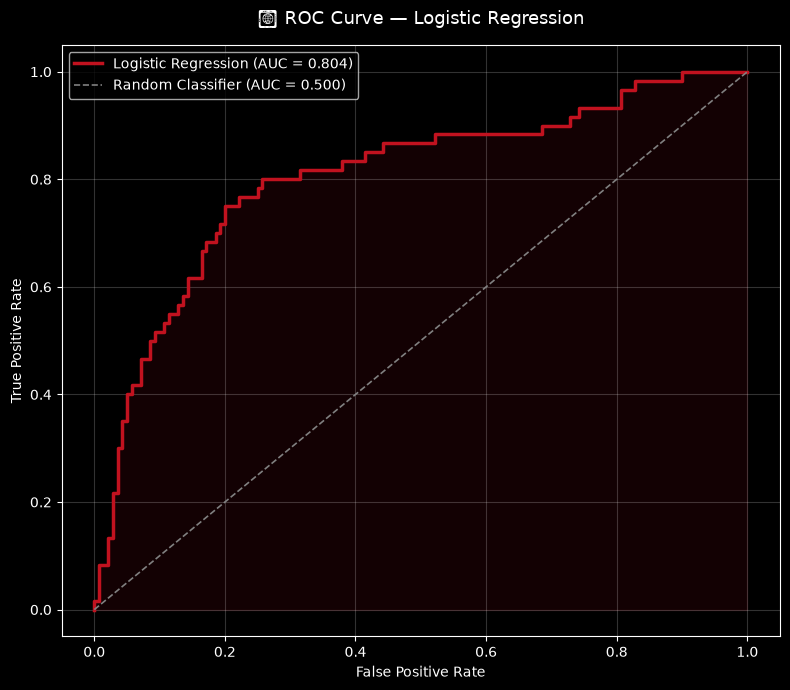

💾 Saved to ../figures/roc_curve_lr.png


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 7))

# Plot the ROC curve
ax.plot(fpr, tpr, color="#c1121f", linewidth=2.5,
        label=f"Logistic Regression (AUC = {auc:.3f})")

# Plot the random classifier baseline — a model with no skill
ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
        linewidth=1.2, label="Random Classifier (AUC = 0.500)")

# Shade the area under the curve for visual impact
ax.fill_between(fpr, tpr, alpha=0.1, color="#c1121f")

ax.set_title("📈 ROC Curve — Logistic Regression", fontsize=13, pad=15)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/roc_curve_lr.png", dpi=150)
plt.show()
print(f"💾 Saved to ../figures/roc_curve_lr.png")

### 📍 Step 3: Precision-Recall Curve

The precision-recall curve is more informative than ROC-AUC for
imbalanced datasets. It plots:
- **Precision** — of all borrowers we flagged as likely defaulters,
  what fraction actually defaulted?
- **Recall** — of all actual defaulters, what fraction did we catch?

The trade-off between these two is the central operational decision
for a lender. A conservative lender prioritises recall — catch as
many defaulters as possible, even at the cost of rejecting some good
borrowers. An aggressive lender prioritises precision — only flag
borrowers you are confident about. The dashed baseline represents
a random classifier — it equals the proportion of defaulters (0.30).

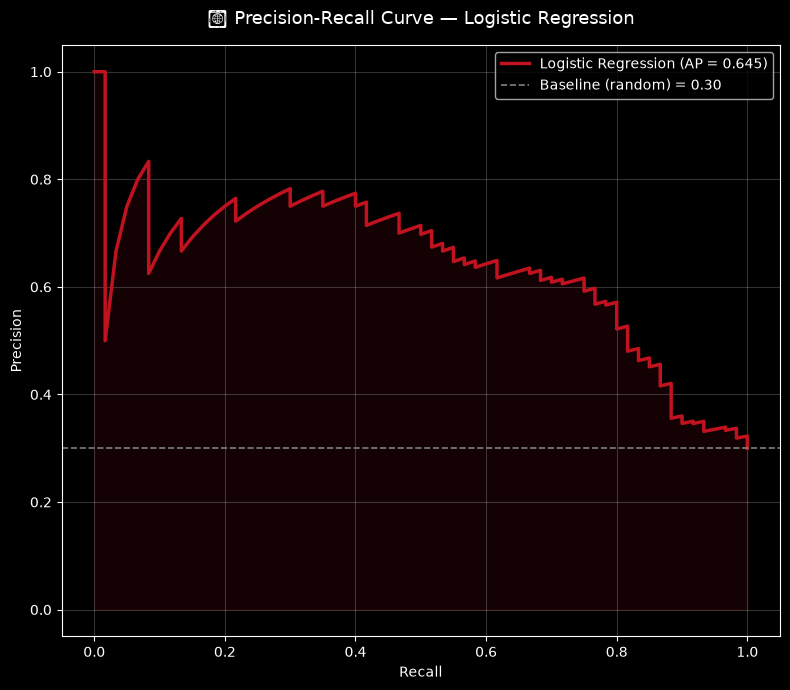

💾 Saved to ../figures/precision_recall_lr.png


In [9]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test, y_pred_proba
)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(recall, precision, color="#c1121f", linewidth=2.5,
        label=f"Logistic Regression (AP = {ap:.3f})")

# Baseline — a random classifier's precision equals the class prevalence
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           linewidth=1.2,
           label=f"Baseline (random) = {y_test.mean():.2f}")

ax.fill_between(recall, precision, alpha=0.1, color="#c1121f")

ax.set_title("📉 Precision-Recall Curve — Logistic Regression",
             fontsize=13, pad=15)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/precision_recall_lr.png", dpi=150)
plt.show()
print(f"💾 Saved to ../figures/precision_recall_lr.png")

### 📍 Step 4: Confusion Matrix

The confusion matrix shows raw counts of correct and incorrect
predictions at the default threshold of 0.5:
- **True Negatives (top left)** — correctly predicted repaid
- **False Positives (top right)** — predicted default, actually repaid
- **False Negatives (bottom left)** — predicted repaid, actually defaulted
- **True Positives (bottom right)** — correctly predicted default

In credit risk, false negatives are typically more costly than false
positives — a missed defaulter costs the bank the full loan amount,
while a false positive only costs a lost interest margin. This
asymmetry is why 0.5 is rarely the optimal threshold in practice.

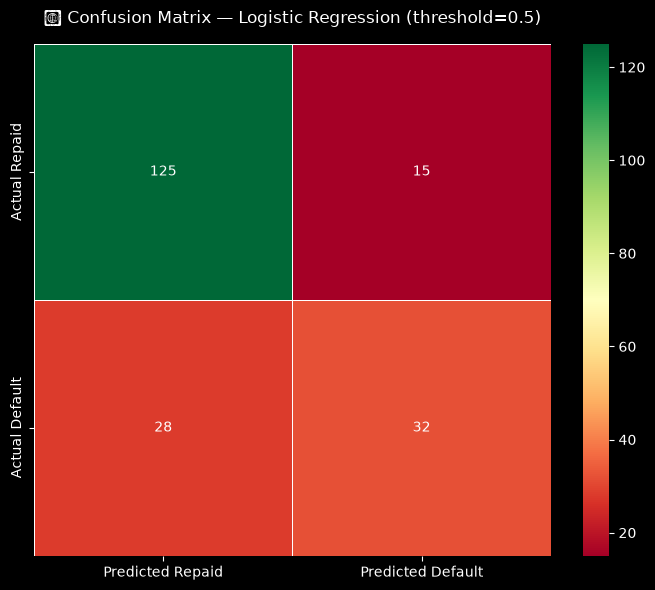

💾 Saved to ../figures/confusion_matrix_lr.png


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdYlGn",
    xticklabels=["Predicted Repaid", "Predicted Default"],
    yticklabels=["Actual Repaid", "Actual Default"],
    linewidths=0.5,
    ax=ax
)
ax.set_title("📊 Confusion Matrix — Logistic Regression (threshold=0.5)",
             fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_lr.png", dpi=150)
plt.show()
print(f"💾 Saved to ../figures/confusion_matrix_lr.png")

## 🔍 Section 5: Interpret Coefficients

### 📍 Top Feature Coefficients

In logistic regression, each feature has a coefficient that tells us
its contribution to the log-odds of default. A positive coefficient
means higher values of that feature increase the probability of
default. A negative coefficient means higher values decrease it.

We plot the top 15 features by absolute coefficient magnitude using
a dot plot — the dot marks the coefficient estimate and the
horizontal line shows the uncertainty around it. This is one of
logistic regression's key advantages over XGBoost — every prediction
can be traced back to a weighted sum of interpretable features,
which is exactly what regulators require for credit decision auditing.

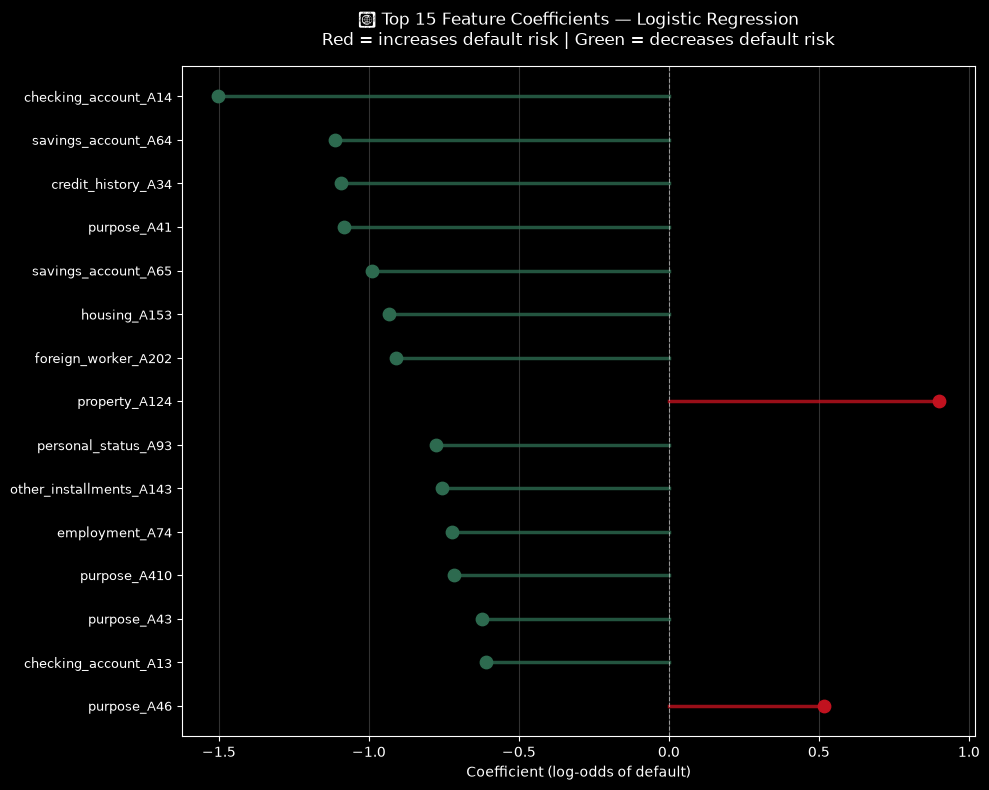

💾 Saved to ../figures/coefficients_lr.png


In [11]:
# Build a DataFrame of feature names and their coefficients
coef_df = pd.DataFrame({
    "feature"    : X.columns,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(coef_df))

# Draw horizontal lines from zero to the coefficient value
for j, (_, row) in enumerate(coef_df.iterrows()):
    color = "#c1121f" if row["coefficient"] > 0 else "#2d6a4f"
    ax.plot([0, row["coefficient"]], [j, j],
            color=color, linewidth=2.5, alpha=0.8)
    # Draw dot at the coefficient value
    ax.scatter(row["coefficient"], j,
               color=color, s=80, zorder=5)

ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df["feature"], fontsize=9)
ax.set_title("🔍 Top 15 Feature Coefficients — Logistic Regression\n"
             "Red = increases default risk | Green = decreases default risk",
             fontsize=12, pad=15)
ax.set_xlabel("Coefficient (log-odds of default)")
ax.grid(alpha=0.2, axis="x")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../figures/coefficients_lr.png", dpi=150)
plt.show()
print(f"💾 Saved to ../figures/coefficients_lr.png")

## 🎯 Section 6: Decision Threshold Analysis

### 📍 Threshold Analysis

The default decision threshold of 0.5 is rarely optimal for credit
risk. Because false negatives (missed defaulters) are more costly
than false positives (rejected good borrowers), a lender might
prefer a lower threshold like 0.3 or 0.4 — accepting more false
positives in exchange for catching more actual defaulters.

This analysis plots precision, recall and F1 score across all
possible thresholds so we can identify the point that best fits
our risk appetite. The F1 score — harmonic mean of precision and
recall — gives a single metric that balances both.

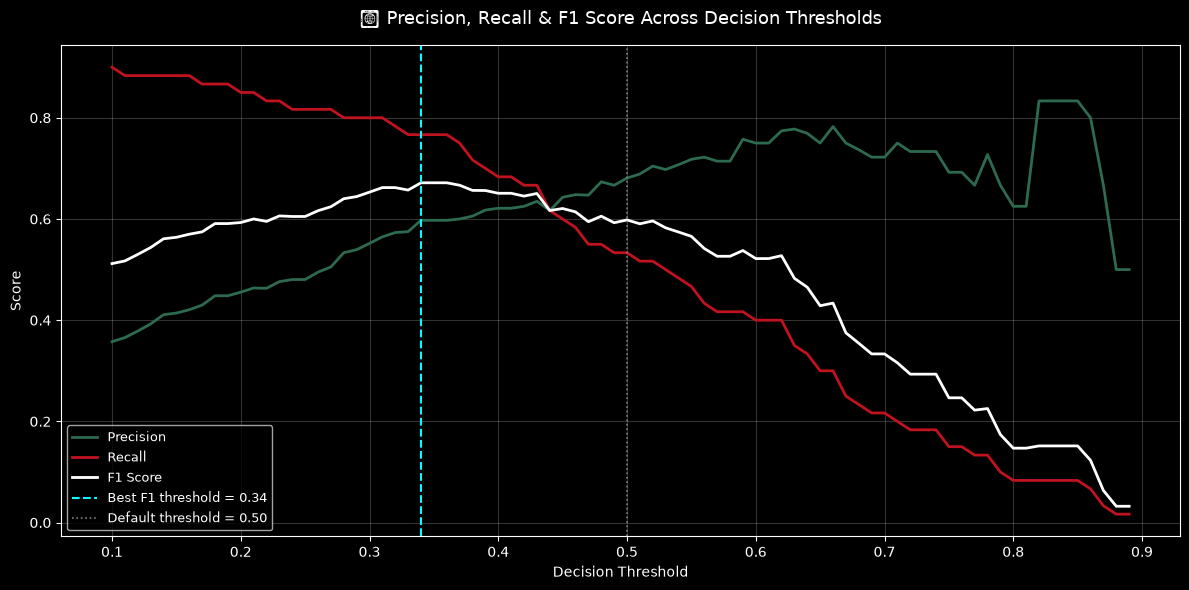

💡 Best F1 threshold : 0.34
   Precision at best : 0.597
   Recall at best    : 0.767
   F1 at best        : 0.672


In [12]:
thres_range = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1_scores = [], [], []

for t in thres_range:
    y_pred_t = (y_pred_proba >= t).astype(int)

    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()

    # Avoid division by zero
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

# Find the threshold that maximises F1 score
best_idx       = np.argmax(f1_scores)
best_threshold = thres_range[best_idx]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thres_range, precisions, color="#2d6a4f",
        linewidth=2, label="Precision")
ax.plot(thres_range, recalls,    color="#c1121f",
        linewidth=2, label="Recall")
ax.plot(thres_range, f1_scores,  color="white",
        linewidth=2, label="F1 Score")

# Mark the best F1 threshold
ax.axvline(best_threshold, color="cyan", linestyle="--",
           linewidth=1.5,
           label=f"Best F1 threshold = {best_threshold:.2f}")

# Mark the default 0.5 threshold for reference
ax.axvline(0.5, color="gray", linestyle=":",
           linewidth=1.2, label="Default threshold = 0.50")

ax.set_title("🎯 Precision, Recall & F1 Score Across Decision Thresholds",
             fontsize=13, pad=15)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/threshold_analysis_lr.png", dpi=150)
plt.show()

print(f"💡 Best F1 threshold : {best_threshold:.2f}")
print(f"   Precision at best : {precisions[best_idx]:.3f}")
print(f"   Recall at best    : {recalls[best_idx]:.3f}")
print(f"   F1 at best        : {f1_scores[best_idx]:.3f}")

## 💾 Section 7: Save Predictions

### 📍 Save Predicted Probabilities

In [13]:
# Save actual labels, predicted probabilities and binary predictions
# NB04 will load this to compare XGBoost performance directly against
# logistic regression on the same test set
predictions_df = pd.DataFrame({
    "actual"          : y_test.values,
    "predicted_proba" : y_pred_proba,
    "predicted_label" : y_pred
})

PRED_PATH = "../data/processed/lr_predictions.csv"
predictions_df.to_csv(PRED_PATH, index=False)

print("✅ Predictions saved:")
print(f"   📄 {PRED_PATH}")
print(f"\n📊 Summary:")
print(f"   ROC-AUC           : {auc:.3f}")
print(f"   Average Precision : {ap:.3f}")
print(f"   Best F1 threshold : {best_threshold:.2f}")
print(f"\n🚀 Ready for NB04 — XGBoost")

✅ Predictions saved:
   📄 ../data/processed/lr_predictions.csv

📊 Summary:
   ROC-AUC           : 0.804
   Average Precision : 0.645
   Best F1 threshold : 0.34

🚀 Ready for NB04 — XGBoost


## 🪞 Personal Reflection Notes — NB03

**🎯 Key Decisions Made in This Notebook**

The first decision was to use logistic regression as the baseline model rather than jumping straight to XGBoost. Logistic regression is the industry standard for credit scoring precisely because of its transparency — every coefficient directly tells you the direction and magnitude of each feature's contribution to default risk. Regulators require banks to explain credit decisions to applicants, and logistic regression is the only model where you can point to a specific coefficient and say "this feature increased your default probability by X". XGBoost will likely outperform it in NB04, but logistic regression sets the interpretability benchmark that any more complex model needs to justify surpassing.

The second decision was to use ROC-AUC and Average Precision as the primary evaluation metrics rather than accuracy. Accuracy of 79% sounds reasonable until you realise a model predicting "repaid" for every single applicant would achieve 70% accuracy — the class prevalence baseline — while catching zero defaulters. ROC-AUC measures how well the model separates defaulters from non-defaulters across all possible thresholds, which is a much more honest measure of discriminative power. Average Precision is even more informative for imbalanced datasets because it focuses specifically on performance in the minority class — the defaulters — which is the group the bank actually cares about most.

The third decision was to run the threshold analysis rather than accepting the default 0.5 cutoff. The 0.5 threshold is arbitrary and almost never optimal for credit risk because the cost asymmetry is severe — a missed defaulter costs the bank the full loan amount while a false positive only costs a lost interest margin. The threshold analysis directly answers what the optimal operating point is given the model's precision-recall trade-off.

**📊 What the Results Revealed**

The overall model performance was strong for a baseline. ROC-AUC of 0.804 sits comfortably within the 0.75-0.85 range considered good for credit scoring models. The 5-fold cross-validation confirmed this was not a lucky test set result — scores ranged from 0.758 to 0.817 with a mean of 0.785 and standard deviation of only 0.019, indicating the model generalises consistently across different subsets of the data.

The confusion matrix at the default 0.5 threshold revealed the core challenge. Of the 60 actual defaulters in the test set, the model correctly identified 32 (recall of 53%) but missed 28 — nearly half the defaulters were labelled as repaid. This is the false negative problem that makes 0.5 a poor threshold for credit risk. The model was more conservative with its positive predictions — of the 47 borrowers it flagged as likely defaulters, 32 actually defaulted (precision of 68%), meaning roughly 1 in 3 flags was a false alarm.

The threshold analysis was the most practically useful result. Lowering the threshold to 0.34 improved recall dramatically from 53% to 76.7% — meaning the model now catches 46 out of 60 actual defaulters rather than 32. The trade-off is that precision drops from 68% to 59.7% — more false alarms. For a bank that weighs missed defaulters more heavily than rejected good borrowers, a threshold of 0.34 is clearly preferable to 0.5. The F1 score also improved from 0.60 to 0.672, confirming that 0.34 is a better balanced operating point even before considering the cost asymmetry.

The coefficient plot revealed that checking_account_A14 had by far the largest negative coefficient — meaning borrowers with no checking account (A14 in the UCI coding) had the lowest predicted probability of default. This is counterintuitive at first glance but makes sense on reflection: borrowers with no checking account may be more financially conservative, avoid credit, and have fewer financial obligations overall. savings_account_A64 and credit_history_A34 were also strongly negative — high savings and a clean credit history are powerful protective factors, exactly as credit risk theory predicts. The only significantly positive coefficients were property_A124 and purpose_A46, suggesting certain property types and loan purposes are associated with elevated default risk.

The precision-recall curve confirmed the model is genuinely useful — it sits well above the 0.30 random baseline across the full recall range. The curve shape shows a reasonable precision of around 0.75 can be maintained up to recall of about 0.40, before it starts degrading more rapidly. This means the model can flag the riskiest 40% of defaulters with high confidence before the signal quality degrades — a useful operating range for a conservative lender.

**🔜 What This Sets Up for NB04**

The key benchmarks to beat in NB04 are ROC-AUC of 0.804 and Average Precision of 0.645. XGBoost should improve on both by capturing the non-linear relationships — particularly the age threshold effect identified in NB02 — and feature interactions that logistic regression cannot model. The coefficient plot also showed that many of the most important features are categorical dummy variables rather than the numerical features we identified as strongest in NB02, which suggests XGBoost's ability to handle mixed feature types and interactions may unlock additional predictive signal that logistic regression left on the table.